y_train range: -1.3254562156773704 7.040078404901302
Running: {'optimizer_name': 'sgd', 'init_type': 'he'}
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step
Running: {'optimizer_name': 'adam', 'init_type': 'he'}
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step
Running: {'optimizer_name': 'rmsprop', 'init_type': 'he'}
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step


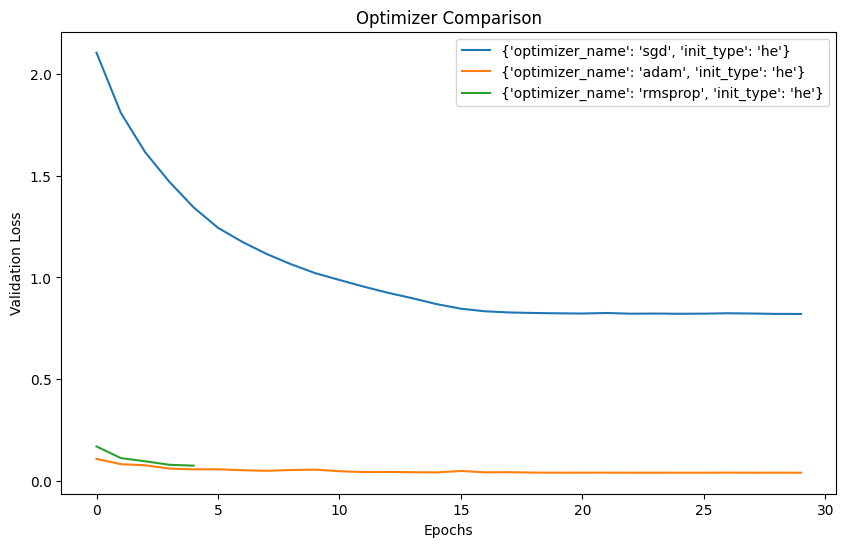

Best Config: {'optimizer_name': 'adam', 'init_type': 'he'}
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step
MAE: 901577.2552864583
RMSE: 1228245.9471227906
R2: 0.9660002206224246


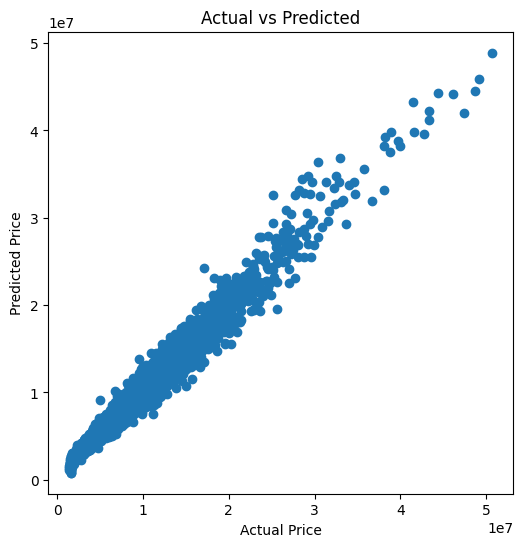

Actual: 4,974,421 | Predicted: 5,454,297
Actual: 5,558,515 | Predicted: 5,240,926
Actual: 14,959,629 | Predicted: 13,533,856
Actual: 1,562,114 | Predicted: 2,093,532
Actual: 3,745,098 | Predicted: 3,877,724


In [1]:
# =========================
# 1. IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.initializers import GlorotUniform, HeNormal
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping


# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("house_price_dataset_india_12k.csv")

# Fix column name issues
df.columns = df.columns.str.strip()

# Drop unwanted columns
df = df.drop(columns=["House_ID", "Price_per_sqft_INR"], errors="ignore")

# Features & target
X = df.drop("Market_Price_INR", axis=1)
y = df["Market_Price_INR"]


# =========================
# 3. PREPROCESSING
# =========================

categorical_nominal = ["City", "Furnishing"]
categorical_ordinal = ["Locality_Tier"]

# Ordinal mapping
locality_map = {"Budget": 0, "Mid": 1, "Premium": 2}
X["Locality_Tier"] = X["Locality_Tier"].map(locality_map)

numerical_cols = [col for col in X.columns if col not in categorical_nominal + categorical_ordinal]

# Column transformer
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_nominal)
])

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Transform X
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# 🔥 SCALE TARGET (CRITICAL FIX)
y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test = y_scaler.transform(y_test.values.reshape(-1,1))

print("y_train range:", y_train.min(), y_train.max())  # should be ~(-2,2)

# Save preprocessor + y scaler
os.makedirs("model", exist_ok=True)
joblib.dump(preprocessor, "model/scaler.pkl")
joblib.dump(y_scaler, "model/y_scaler.pkl")


# =========================
# 4. MODEL BUILDER
# =========================
def build_model(optimizer_name="adam", init_type="he", regularizer_type=None,
                use_bn=True, dropout_rate=0.3):

    initializer = HeNormal() if init_type == "he" else GlorotUniform()

    reg = None
    if regularizer_type == "l1":
        reg = l1(0.001)
    elif regularizer_type == "l2":
        reg = l2(0.001)

    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))

    model.add(Dense(128, kernel_initializer=initializer, kernel_regularizer=reg))
    if use_bn:
        model.add(BatchNormalization())
    model.add(tf.keras.layers.ReLU())
    model.add(Dropout(dropout_rate))

    model.add(Dense(64, kernel_initializer=initializer, kernel_regularizer=reg))
    if use_bn:
        model.add(BatchNormalization())
    model.add(tf.keras.layers.ReLU())

    model.add(Dense(32, kernel_initializer=initializer))
    model.add(tf.keras.layers.ReLU())

    model.add(Dense(1, activation='linear'))

    # 🔥 SAFE OPTIMIZERS
    if optimizer_name == "sgd":
        optimizer = SGD(learning_rate=0.0001, clipnorm=1.0)
    elif optimizer_name == "rmsprop":
        optimizer = RMSprop(learning_rate=0.0005, clipnorm=1.0)
    else:
        optimizer = Adam(learning_rate=0.001, clipnorm=1.0)

    model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

    return model


# =========================
# 5. CALLBACKS
# =========================
def lr_schedule(epoch, lr):
    if epoch > 15:
        return lr * 0.5
    return lr

early_stop = EarlyStopping(patience=5, restore_best_weights=True)


# =========================
# 6. TRAIN FUNCTION
# =========================
def train_model(config):
    model = build_model(**config)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=30,
        batch_size=32,
        verbose=0,
        callbacks=[LearningRateScheduler(lr_schedule), early_stop]
    )

    return model, history


# =========================
# 7. EXPERIMENTS
# =========================
experiments = [
    {"optimizer_name": "sgd", "init_type": "he"},
    {"optimizer_name": "adam", "init_type": "he"},
    {"optimizer_name": "rmsprop", "init_type": "he"},
]

results = {}

for config in experiments:
    print("Running:", config)

    model, history = train_model(config)

    y_pred_scaled = model.predict(X_test)

    y_pred = y_scaler.inverse_transform(y_pred_scaled)
    y_test_actual = y_scaler.inverse_transform(y_test)

    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
    mae = mean_absolute_error(y_test_actual, y_pred)

    results[str(config)] = {
        "history": history.history,
        "rmse": rmse,
        "mae": mae,
        "model": model
    }


# =========================
# 8. PLOT OPTIMIZER COMPARISON
# =========================
plt.figure(figsize=(10,6))

for name, res in results.items():
    plt.plot(res["history"]["val_loss"], label=name)

plt.title("Optimizer Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()


# =========================
# 9. BEST MODEL
# =========================
best_key = min(results, key=lambda x: results[x]["rmse"])
best_model = results[best_key]["model"]

print("Best Config:", best_key)


# =========================
# 10. SAVE MODEL
# =========================
best_model.save("model/best_model.keras")


# =========================
# 11. FINAL EVALUATION
# =========================
y_pred_scaled = best_model.predict(X_test)

y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_test_actual = y_scaler.inverse_transform(y_test)

print("MAE:", mean_absolute_error(y_test_actual, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_pred)))
print("R2:", r2_score(y_test_actual, y_pred))


# =========================
# 12. PLOTS
# =========================
plt.figure(figsize=(6,6))
plt.scatter(y_test_actual, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()


# =========================
# 13. SAMPLE PREDICTIONS
# =========================
for i in range(5):
    print(f"Actual: {y_test_actual[i][0]:,.0f} | Predicted: {y_pred[i][0]:,.0f}")